# House Price Prediction System
## Model Development Notebook
This notebook develops a machine learning model to predict house prices using selected features from the dataset.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

## 2. Load and Explore the Dataset

In [2]:
# Load the dataset
df = pd.read_csv('model/house_prices_train.csv')

# Display dataset information
print("Dataset Shape:", df.shape)
print("\nFirst Few Rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())

Dataset Shape: (1460, 81)

First Few Rows:
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleC

In [3]:
# Check for missing values
print("Missing Values:")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_data.index,
    'Missing Count': missing_data.values,
    'Percentage': missing_percent.values
})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))

Missing Values:
          Column  Missing Count  Percentage
72        PoolQC           1453   99.520548
74   MiscFeature           1406   96.301370
6          Alley           1369   93.767123
73         Fence           1179   80.753425
25    MasVnrType            872   59.726027
57   FireplaceQu            690   47.260274
3    LotFrontage            259   17.739726
58    GarageType             81    5.547945
59   GarageYrBlt             81    5.547945
60  GarageFinish             81    5.547945
63    GarageQual             81    5.547945
64    GarageCond             81    5.547945
35  BsmtFinType2             38    2.602740
32  BsmtExposure             38    2.602740
33  BsmtFinType1             37    2.534247
31      BsmtCond             37    2.534247
30      BsmtQual             37    2.534247
26    MasVnrArea              8    0.547945
42    Electrical              1    0.068493


## 3. Data Preprocessing and Feature Engineering

In [4]:
# Selected features: OverallQual, GrLivArea, TotalBsmtSF, GarageCars, YearBuilt, Neighborhood
# Target: SalePrice

selected_features = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars', 'YearBuilt', 'Neighborhood']
target = 'SalePrice'

# Create a working dataframe with selected features and target
working_df = df[selected_features + [target]].copy()

print(f"Working DataFrame Shape: {working_df.shape}")
print("\nSelected Features Info:")
print(working_df.info())
print("\nMissing Values in Selected Features:")
print(working_df.isnull().sum())

Working DataFrame Shape: (1460, 7)

Selected Features Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   OverallQual   1460 non-null   int64 
 1   GrLivArea     1460 non-null   int64 
 2   TotalBsmtSF   1460 non-null   int64 
 3   GarageCars    1460 non-null   int64 
 4   YearBuilt     1460 non-null   int64 
 5   Neighborhood  1460 non-null   object
 6   SalePrice     1460 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 80.0+ KB
None

Missing Values in Selected Features:
OverallQual     0
GrLivArea       0
TotalBsmtSF     0
GarageCars      0
YearBuilt       0
Neighborhood    0
SalePrice       0
dtype: int64


In [5]:
# Handle missing values
# For numerical features: fill with median
# For categorical features: fill with mode

for column in working_df.columns:
    if working_df[column].dtype == 'object':
        # Fill categorical features with mode
        working_df[column].fillna(working_df[column].mode()[0], inplace=True)
    else:
        # Fill numerical features with median
        working_df[column].fillna(working_df[column].median(), inplace=True)

print("Missing Values After Handling:")
print(working_df.isnull().sum())
print("\nDataFrame Shape After Preprocessing:", working_df.shape)

Missing Values After Handling:
OverallQual     0
GrLivArea       0
TotalBsmtSF     0
GarageCars      0
YearBuilt       0
Neighborhood    0
SalePrice       0
dtype: int64

DataFrame Shape After Preprocessing: (1460, 7)


## 4. Feature Selection and Encoding

In [6]:
# Separate features and target
X = working_df[selected_features].copy()
y = working_df[target].copy()

# Encode categorical variables (Neighborhood)
label_encoders = {}
categorical_features = X.select_dtypes(include=['object']).columns

for feature in categorical_features:
    le = LabelEncoder()
    X[feature] = le.fit_transform(X[feature])
    label_encoders[feature] = le
    print(f"Encoded {feature}: {len(le.classes_)} unique values")

print("\nFeatures After Encoding:")
print(X.head())
print("\nFeature Data Types:")
print(X.dtypes)

Encoded Neighborhood: 25 unique values

Features After Encoding:
   OverallQual  GrLivArea  TotalBsmtSF  GarageCars  YearBuilt  Neighborhood
0            7       1710          856           2       2003             5
1            6       1262         1262           2       1976            24
2            7       1786          920           2       2001             5
3            7       1717          756           3       1915             6
4            8       2198         1145           3       2000            15

Feature Data Types:
OverallQual     int64
GrLivArea       int64
TotalBsmtSF     int64
GarageCars      int64
YearBuilt       int64
Neighborhood    int32
dtype: object


## 5. Feature Scaling

In [7]:
# Apply feature scaling using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Scaled Features (First 5 rows):")
print(X_scaled.head())
print("\nScaled Features Statistics:")
print(X_scaled.describe())

Scaled Features (First 5 rows):
   OverallQual  GrLivArea  TotalBsmtSF  GarageCars  YearBuilt  Neighborhood
0     0.651479   0.370333    -0.459303    0.311725   1.050994     -1.206215
1    -0.071836  -0.482512     0.466465    0.311725   0.156734      1.954302
2     0.651479   0.515013    -0.313369    0.311725   0.984752     -1.206215
3     0.651479   0.383659    -0.687324    1.650307  -1.863632     -1.039872
4     1.374795   1.299326     0.199680    1.650307   0.951632      0.457215

Scaled Features Statistics:
        OverallQual     GrLivArea   TotalBsmtSF    GarageCars     YearBuilt  \
count  1.460000e+03  1.460000e+03  1.460000e+03  1.460000e+03  1.460000e+03   
mean   1.387018e-16 -1.277517e-16  2.457699e-16  1.216683e-16  1.046347e-15   
std    1.000343e+00  1.000343e+00  1.000343e+00  1.000343e+00  1.000343e+00   
min   -3.688413e+00 -2.249120e+00 -2.411167e+00 -2.365440e+00 -3.287824e+00   
25%   -7.951515e-01 -7.347485e-01 -5.966855e-01 -1.026858e+00 -5.719226e-01   
50%   -7.

## 6. Train-Test Split

In [8]:
# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Training Set Size: {X_train.shape[0]}")
print(f"Testing Set Size: {X_test.shape[0]}")
print(f"\nTraining Set Target Statistics:")
print(y_train.describe())
print(f"\nTesting Set Target Statistics:")
print(y_test.describe())

Training Set Size: 1168
Testing Set Size: 292

Training Set Target Statistics:
count      1168.000000
mean     181441.541952
std       77263.583862
min       34900.000000
25%      130000.000000
50%      165000.000000
75%      214925.000000
max      745000.000000
Name: SalePrice, dtype: float64

Testing Set Target Statistics:
count       292.000000
mean     178839.811644
std       87730.751259
min       35311.000000
25%      127000.000000
50%      154150.000000
75%      209175.000000
max      755000.000000
Name: SalePrice, dtype: float64


## 7. Model Implementation and Training

In [9]:
# Initialize and train Random Forest Regressor
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

print("Training the Random Forest Regressor...")
model.fit(X_train, y_train)
print("Model Training Completed!")

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': selected_features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

Training the Random Forest Regressor...
Model Training Completed!

Feature Importance:
        Feature  Importance
0   OverallQual    0.602041
1     GrLivArea    0.191363
2   TotalBsmtSF    0.096769
4     YearBuilt    0.051862
5  Neighborhood    0.029750
3    GarageCars    0.028216


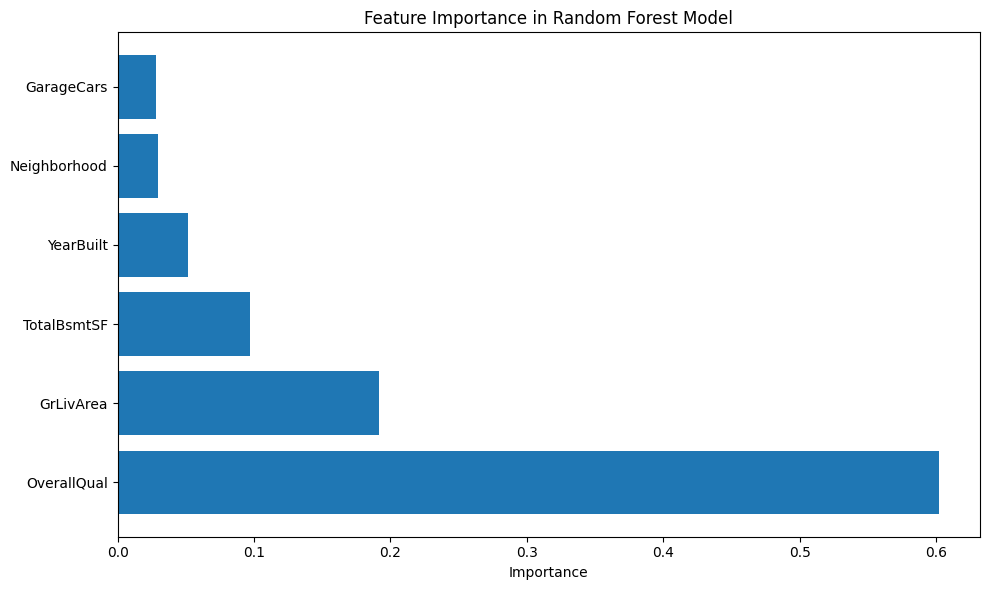

In [10]:
# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance in Random Forest Model')
plt.tight_layout()
plt.show()

## 8. Model Evaluation

In [11]:
# Make predictions on training and testing sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate evaluation metrics for training set
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

# Calculate evaluation metrics for testing set
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

# Display metrics
print("="*50)
print("MODEL EVALUATION METRICS")
print("="*50)
print("\nTRAINING SET METRICS:")
print(f"  Mean Absolute Error (MAE):      ${train_mae:,.2f}")
print(f"  Mean Squared Error (MSE):       ${train_mse:,.2f}")
print(f"  Root Mean Squared Error (RMSE): ${train_rmse:,.2f}")
print(f"  R² Score:                       {train_r2:.4f}")

print("\nTESTING SET METRICS:")
print(f"  Mean Absolute Error (MAE):      ${test_mae:,.2f}")
print(f"  Mean Squared Error (MSE):       ${test_mse:,.2f}")
print(f"  Root Mean Squared Error (RMSE): ${test_rmse:,.2f}")
print(f"  R² Score:                       {test_r2:.4f}")
print("="*50)

MODEL EVALUATION METRICS

TRAINING SET METRICS:
  Mean Absolute Error (MAE):      $10,410.23
  Mean Squared Error (MSE):       $289,485,272.84
  Root Mean Squared Error (RMSE): $17,014.27
  R² Score:                       0.9515

TESTING SET METRICS:
  Mean Absolute Error (MAE):      $18,688.95
  Mean Squared Error (MSE):       $873,728,030.97
  Root Mean Squared Error (RMSE): $29,558.89
  R² Score:                       0.8861


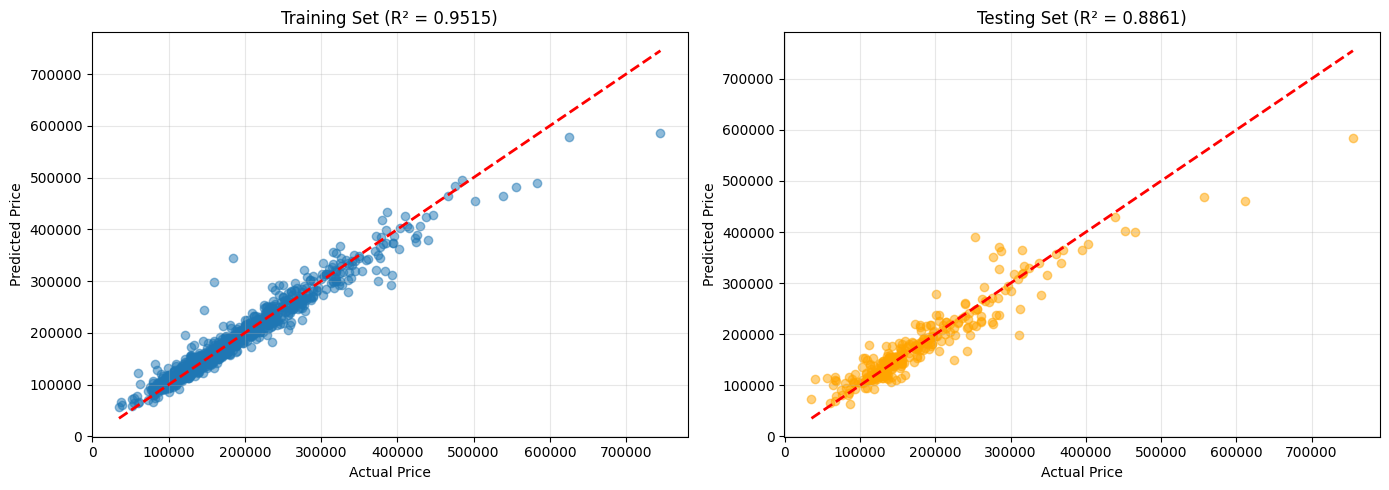

In [12]:
# Visualize predictions vs actual values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set
axes[0].scatter(y_train, y_train_pred, alpha=0.5)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title(f'Training Set (R² = {train_r2:.4f})')
axes[0].grid(True, alpha=0.3)

# Testing set
axes[1].scatter(y_test, y_test_pred, alpha=0.5, color='orange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')
axes[1].set_title(f'Testing Set (R² = {test_r2:.4f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

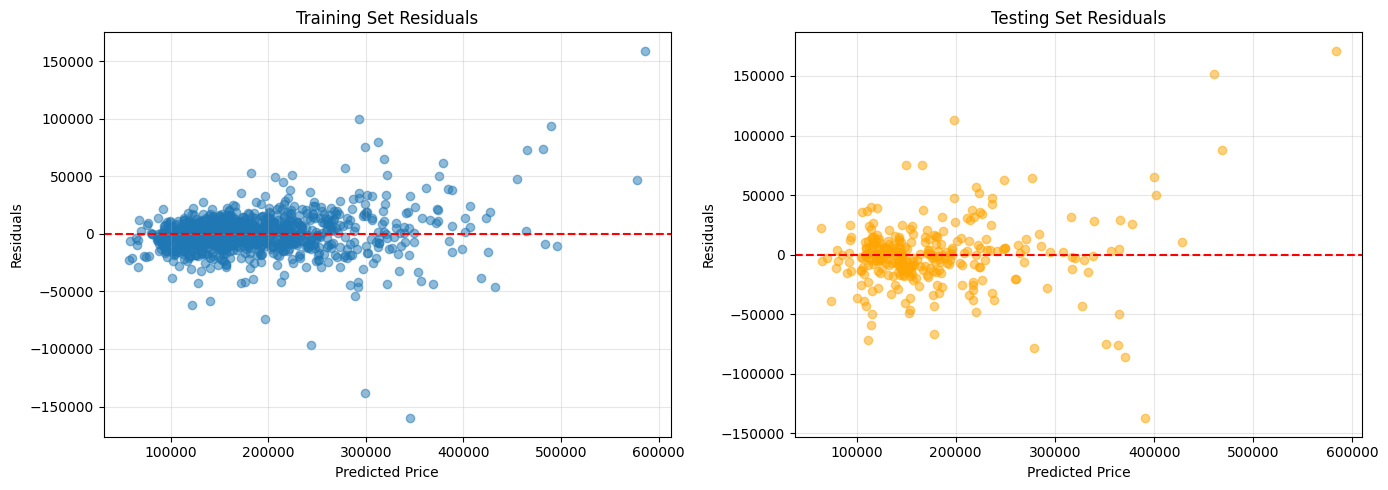

In [13]:
# Residuals analysis
train_residuals = y_train - y_train_pred
test_residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training residuals
axes[0].scatter(y_train_pred, train_residuals, alpha=0.5)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Training Set Residuals')
axes[0].grid(True, alpha=0.3)

# Testing residuals
axes[1].scatter(y_test_pred, test_residuals, alpha=0.5, color='orange')
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Testing Set Residuals')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Model Persistence

In [14]:
# Save the trained model using joblib
model_path = 'model/house_price_model.pkl'
joblib.dump(model, model_path)
print(f"Model saved to {model_path}")

# Save the scaler
scaler_path = 'model/scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f"Scaler saved to {scaler_path}")

# Save the label encoders
encoders_path = 'model/label_encoders.pkl'
joblib.dump(label_encoders, encoders_path)
print(f"Label encoders saved to {encoders_path}")

Model saved to model/house_price_model.pkl
Scaler saved to model/scaler.pkl
Label encoders saved to model/label_encoders.pkl


In [15]:
# Verify that the model can be reloaded
print("Verifying Model Persistence...\n")

# Reload the model
loaded_model = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)
loaded_encoders = joblib.load(encoders_path)

print("✓ Model reloaded successfully")
print("✓ Scaler reloaded successfully")
print("✓ Label encoders reloaded successfully")

# Test the reloaded model
y_test_pred_reloaded = loaded_model.predict(X_test)
r2_reloaded = r2_score(y_test, y_test_pred_reloaded)

print(f"\n✓ Reloaded model R² Score on test set: {r2_reloaded:.4f}")
print("\n✅ Model persistence verification completed successfully!")

Verifying Model Persistence...

✓ Model reloaded successfully
✓ Scaler reloaded successfully
✓ Label encoders reloaded successfully

✓ Reloaded model R² Score on test set: 0.8861

✅ Model persistence verification completed successfully!


In [16]:
# Save feature names and selected features for use in web app
config = {
    'selected_features': selected_features,
    'model_algorithm': 'Random Forest Regressor',
    'model_metrics': {
        'test_r2': float(test_r2),
        'test_rmse': float(test_rmse),
        'test_mae': float(test_mae)
    }
}

import json
config_path = 'model/model_config.json'
with open(config_path, 'w') as f:
    json.dump(config, f, indent=4)

print(f"Configuration saved to {config_path}")
print("\nModel Configuration:")
print(json.dumps(config, indent=4))

Configuration saved to model/model_config.json

Model Configuration:
{
    "selected_features": [
        "OverallQual",
        "GrLivArea",
        "TotalBsmtSF",
        "GarageCars",
        "YearBuilt",
        "Neighborhood"
    ],
    "model_algorithm": "Random Forest Regressor",
    "model_metrics": {
        "test_r2": 0.886089847110292,
        "test_rmse": 29558.890895543074,
        "test_mae": 18688.95039505491
    }
}
